In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from pyproj import Transformer
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import DBSCAN

In [2]:
RANDOM_STATE = 42

PLOT_SAMPLE_SIZE = 50000
SCORE_SAMPLE_SIZE = 20000
EVAL_FEATURE_SET_SAMPLE_SIZE = 20000

K_RANGE = range(1, 21)
K_RANGE_SIL = range(2, 21)

BEST_K = None

DBSCAN_SAMPLE_SIZE = 50000
DBSCAN_EPS = None
DBSCAN_MIN_SAMPLES = None

In [3]:
df = pd.read_csv("Divar_Iran.csv", low_memory=False)

In [4]:
print(df.shape)

(995939, 61)


In [5]:
cols = [
    "price_value",
    "building_size",
    "rooms_count",
    "location_latitude",
    "location_longitude",
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "has_pool",
    "has_heating_system",
    "has_cooling_system"
]

In [6]:
df[cols].isna().sum()

price_value           429562
building_size          19515
rooms_count           153538
location_latitude     344392
location_longitude    344392
has_parking           270572
has_elevator          456402
has_warehouse         270573
has_balcony           491172
has_pool              966657
has_heating_system    627596
has_cooling_system    646328
dtype: int64

In [7]:
df_rec = df[cols].copy()

In [8]:
print(df_rec.info())
print(df_rec.isna().sum())
print(df_rec.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995939 entries, 0 to 995938
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         566377 non-null  float64
 1   building_size       976424 non-null  float64
 2   rooms_count         842401 non-null  object 
 3   location_latitude   651547 non-null  float64
 4   location_longitude  651547 non-null  float64
 5   has_parking         725367 non-null  object 
 6   has_elevator        539537 non-null  object 
 7   has_warehouse       725366 non-null  object 
 8   has_balcony         504767 non-null  object 
 9   has_pool            29282 non-null   object 
 10  has_heating_system  368343 non-null  object 
 11  has_cooling_system  349611 non-null  object 
dtypes: float64(4), object(8)
memory usage: 91.2+ MB
None
price_value           429562
building_size          19515
rooms_count           153538
location_latitude     344392
location_longit

In [9]:
df_rec.head()

,price_value,building_size,rooms_count,location_latitude,location_longitude,has_parking,has_elevator,has_warehouse,has_balcony,has_pool,has_heating_system,has_cooling_system
0,NaN,500.0,سه,35.811684,50.936600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,132.0,سه,35.703865,51.373459,True,True,True,NaN,NaN,NaN,NaN
2,8.700000e+09,100.0,دو,35.729832,51.505466,True,True,True,NaN,NaN,NaN,NaN
3,6.500000e+08,78.0,دو,35.712364,50.794781,True,True,True,true,NaN,shoofaj,water_cooler
4,2.600000e+09,87.0,دو,35.778664,51.757549,True,True,True,true,NaN,shoofaj,water_cooler


In [10]:
room_map = {
    "بدون اتاق": 0,
    "یک": 1,
    "دو": 2,
    "سه": 3,
    "چهار": 4,
    "پنج یا بیشتر": 5
}

df_rec["rooms_count"] = df_rec["rooms_count"].map(room_map)

In [11]:
df_rec["rooms_count"].value_counts(dropna=False)

rooms_count
2.0    402472
1.0    191365
NaN    153538
3.0    137979
0.0     75476
4.0     21287
5.0     13822
Name: count, dtype: int64

In [12]:
bool_map = {
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
    "true": 1,
    "false": 0,
    "TRUE": 1,
    "FALSE": 0,
    1: 1,
    0: 0
}

bool_cols = [
    "has_parking",
    "has_elevator",
    "has_warehouse",
    "has_balcony",
    "has_pool",
    "has_heating_system",
    "has_cooling_system"
]

for col in bool_cols:
    df_rec[col] = df_rec[col].map(bool_map)

In [13]:
for col in bool_cols:
    print(df_rec[col].value_counts(dropna=False))

has_parking
1.0    550316
NaN    270572
0.0    175051
Name: count, dtype: int64
has_elevator
NaN    456402
1.0    363397
0.0    176140
Name: count, dtype: int64
has_warehouse
1.0    580930
NaN    270573
0.0    144436
Name: count, dtype: int64
has_balcony
NaN    491395
1.0    411486
0.0     93058
Name: count, dtype: int64
has_pool
NaN    966657
0.0     25578
1.0      3704
Name: count, dtype: int64
has_heating_system
NaN    995939
Name: count, dtype: int64
has_cooling_system
NaN    995939
Name: count, dtype: int64


In [14]:
df_rec.isna().sum()

price_value           429562
building_size          19515
rooms_count           153538
location_latitude     344392
location_longitude    344392
has_parking           270572
has_elevator          456402
has_warehouse         270573
has_balcony           491395
has_pool              966657
has_heating_system    995939
has_cooling_system    995939
dtype: int64

In [15]:
df_rec = df_rec.dropna(subset=[
    "location_latitude",
    "location_longitude"
]).copy()

df_rec.shape

(651547, 12)

In [16]:
df_rec = df_rec.dropna(subset=[
    "price_value"
]).copy()

df_rec.shape

(370150, 12)

In [17]:
df_rec = df_rec[df_rec["price_value"] > 0].copy()

df_rec.shape

(368954, 12)

In [18]:
low_q = df_rec["price_value"].quantile(0.01)
high_q = df_rec["price_value"].quantile(0.99)

df_rec = df_rec[
    (df_rec["price_value"] >= low_q) &
    (df_rec["price_value"] <= high_q)
].copy()

df_rec.shape

(362185, 12)

In [19]:
df_rec["price_value"].describe()

count    3.621850e+05
mean     5.391043e+09
std      8.119804e+09
min      1.111110e+05
25%      1.500000e+09
50%      2.900000e+09
75%      5.850000e+09
max      8.500000e+10
Name: price_value, dtype: float64

In [20]:
df_rec["log_price"] = np.log1p(df_rec["price_value"])

In [21]:
df_rec["log_price"].describe()

count    362185.000000
mean         21.720174
std           1.404028
min          11.618294
25%          21.128731
50%          21.787977
75%          22.489707
max          25.165917
Name: log_price, dtype: float64

In [22]:
for col in bool_cols:
    df_rec[col] = df_rec[col].fillna(0)

In [23]:
df_rec["rooms_count"] = df_rec["rooms_count"].fillna(df_rec["rooms_count"].median())

In [24]:
df_rec["building_size"] = df_rec["building_size"].fillna(df_rec["building_size"].median())

In [25]:
df_rec.describe()

,price_value,building_size,rooms_count,location_latitude,location_longitude,has_parking,has_elevator,has_warehouse,has_balcony,has_pool,has_heating_system,has_cooling_system,log_price
count,3.621850e+05,3.621850e+05,362185.000000,362185.000000,362185.000000,362185.000000,362185.000000,362185.000000,362185.000000,362185.000000,362185.0,362185.0,362185.000000
mean,5.391043e+09,1.677443e+03,1.972751,35.108713,51.542344,0.616290,0.403396,0.650259,0.493924,0.004799,0.0,0.0,21.720174
std,8.119804e+09,8.248242e+04,0.816635,2.270706,3.103703,0.486289,0.490580,0.476889,0.499964,0.069106,0.0,0.0,1.404028
min,1.111110e+05,1.000000e+00,0.000000,25.258112,44.147614,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,11.618294
25%,1.500000e+09,7.600000e+01,2.000000,34.780563,50.560932,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,21.128731
50%,2.900000e+09,1.060000e+02,2.000000,35.726246,51.325760,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,21.787977
75%,5.850000e+09,1.800000e+02,2.000000,36.355976,51.817215,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,22.489707
max,8.500000e+10,1.000000e+07,5.000000,39.678127,62.707977,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,25.165917


In [26]:
df_rec = df_rec[
    (df_rec["building_size"] >= 10) &
    (df_rec["building_size"] <= 1000) &
    (df_rec["location_latitude"].between(24, 40)) &
    (df_rec["location_longitude"].between(43, 64))
].copy()

df_rec.shape

(348222, 13)

In [27]:
df_rec.isna().sum()

price_value           0
building_size         0
rooms_count           0
location_latitude     0
location_longitude    0
has_parking           0
has_elevator          0
has_warehouse         0
has_balcony           0
has_pool              0
has_heating_system    0
has_cooling_system    0
log_price             0
dtype: int64

In [28]:
print(df_rec.info())
print(df_rec.isna().sum())
print(df_rec.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 348222 entries, 2 to 651543
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price_value         348222 non-null  float64
 1   building_size       348222 non-null  float64
 2   rooms_count         348222 non-null  float64
 3   location_latitude   348222 non-null  float64
 4   location_longitude  348222 non-null  float64
 5   has_parking         348222 non-null  float64
 6   has_elevator        348222 non-null  float64
 7   has_warehouse       348222 non-null  float64
 8   has_balcony         348222 non-null  float64
 9   has_pool            348222 non-null  float64
 10  has_heating_system  348222 non-null  float64
 11  has_cooling_system  348222 non-null  float64
 12  log_price           348222 non-null  float64
dtypes: float64(13)
memory usage: 37.2 MB
None
price_value           0
building_size         0
rooms_count           0
location_latitude     0
l

In [29]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32639", always_xy=True)

utm_x, utm_y = transformer.transform(
    df_rec["location_longitude"].values,
    df_rec["location_latitude"].values
)

df_rec["utm_x"] = utm_x
df_rec["utm_y"] = utm_y

In [30]:
df_rec[[
    "location_latitude",
    "location_longitude",
    "utm_x",
    "utm_y"
]].head()

,location_latitude,location_longitude,utm_x,utm_y
2,35.729832,51.505466,5.457116e+05,3.954101e+06
3,35.712364,50.794781,4.814371e+05,3.952066e+06
4,35.778664,51.757549,5.684670e+05,3.959664e+06
6,36.321831,59.524502,1.266003e+06,4.053542e+06
7,32.467804,51.404095,5.379740e+05,3.592362e+06


In [31]:
df_rec[["utm_x", "utm_y"]].describe()

,utm_x,utm_y
count,3.482220e+05,3.482220e+05
mean,5.530621e+05,3.890078e+06
std,2.810800e+05,2.500524e+05
min,-9.094646e+04,2.830544e+06
25%,4.723529e+05,3.854396e+06
50%,5.301578e+05,3.953667e+06
75%,5.738174e+05,4.044201e+06
max,1.660175e+06,4.396489e+06


In [32]:
def evaluate_feature_set(
    df, 
    feature_cols,
    k=10,
    sample_size=EVAL_FEATURE_SET_SAMPLE_SIZE,
    random_state=RANDOM_STATE
):
    X = df[feature_cols].copy()
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    sample_idx = np.random.RandomState(random_state).choice(
        len(X_scaled),
        size=sample_size, 
        replace=False
    )
    
    X_sample = X_scaled[sample_idx]
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample)
    
    return {
        "feature_set": feature_cols,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_sample, labels),
        "calinski_harabasz": calinski_harabasz_score(X_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_sample, labels)
    }

In [33]:
feature_sets = {

    "v1": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_warehouse",
        "has_balcony",
        "has_pool",
        "has_heating_system",
        "has_cooling_system"
    ],

    "v2": [
        "utm_x",
        "utm_y",
        "log_price"
    ],

    "v3": [
        "utm_x",
        "utm_y",
        "log_price",
        "building_size",
        "rooms_count"
    ],

    "v4": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_warehouse"
    ],

    "v5": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y"
    ],

    "v6": [
        "log_price",
        "utm_x",
        "utm_y",
        "building_size",
        "has_parking"
    ],

    "v7": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_elevator",
        "has_balcony"
    ],

    "v8": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_pool",
        "has_balcony",
        "has_parking"
    ],

    "v9": [
        "log_price",
        "building_size",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator"
    ],

    "v10": [
        "log_price",
        "building_size",
        "rooms_count",
        "utm_x",
        "utm_y",
        "has_parking",
        "has_elevator",
        "has_balcony",
        "has_heating_system",
        "has_cooling_system"
    ]
}

In [34]:
results = []

for name, feature_set in feature_sets.items():
    result = evaluate_feature_set(
        df_rec,
        feature_set, 
        k=10
    )
    
    result["name"] = name
    results.append(result)
    
feature_results = pd.DataFrame(results)

feature_results_sorted = feature_results.sort_values(
    "silhouette",
    ascending=False
)

feature_results_sorted

,feature_set,inertia,silhouette,calinski_harabasz,davies_bouldin,name
8,"[log_price, building_size, utm_x, utm_y, has_p...",37354.805093,0.383654,4972.969355,1.057804,v9
1,"[utm_x, utm_y, log_price]",11186.962285,0.360242,9884.484923,0.955790,v2
5,"[log_price, utm_x, utm_y, building_size, has_p...",28672.060639,0.328294,5605.747307,1.034689,v6
6,"[log_price, building_size, rooms_count, utm_x,...",52233.032073,0.301179,3806.048847,1.169365,v7
7,"[log_price, building_size, rooms_count, utm_x,...",54673.007153,0.297845,4344.605813,1.080886,v8
2,"[utm_x, utm_y, log_price, building_size, rooms...",32090.292201,0.282977,4823.616225,1.079650,v3
4,"[log_price, building_size, rooms_count, utm_x,...",32090.292201,0.282977,4823.616225,1.079650,v5
9,"[log_price, building_size, rooms_count, utm_x,...",64121.293712,0.253788,3378.490010,1.318860,v10
3,"[log_price, building_size, rooms_count, utm_x,...",62252.436691,0.246966,3544.008816,1.325249,v4
0,"[log_price, building_size, rooms_count, utm_x,...",78253.663588,0.246700,3498.185758,1.220348,v1


In [35]:
best_feature_set_name = feature_results_sorted.iloc[0]["name"]
print("Best Feature Set: ", best_feature_set_name)

feature_cols = feature_sets[best_feature_set_name]

Best Feature Set:  v9


In [36]:
X = df_rec[feature_cols].copy()

In [37]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [38]:
def run_kmeans_clustering(
    df,
    X_scaled,
    scaler,
    feature_cols,
    bool_cols,
    n_clusters,
    cluster_col_name,
    random_state=RANDOM_STATE
):
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )
    
    df[cluster_col_name] = kmeans.fit_predict(X_scaled)
    
    centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
    
    centers_df = pd.DataFrame(
        centers_original,
        columns=feature_cols
    )
    
    for col in feature_cols:
        if col in bool_cols:
            centers_df[col] = centers_df[col].clip(0, 1)
    
    if "log_price" in centers_df.columns: 
        centers_df["center_price"] = np.expm1(centers_df["log_price"])
        
    centers_df = centers_df.round(2)
    
    cluster_counts = df[cluster_col_name].value_counts().sort_index()
    
    return kmeans, centers_df, cluster_counts

In [39]:
def plot_kmeans_clusters(
    df,
    centers_df,
    cluster_col_name,
    title,
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap_name="tab20"
):
    if len(df) > sample_size:
        plot_df = df.sample(n=sample_size, random_state=random_state)
    else:
        plot_df = df.copy()

    labels = sorted(plot_df[cluster_col_name].unique())

    base_cmap = plt.get_cmap(cmap_name)
    colors = [base_cmap(i) for i in range(len(labels))]

    cmap = ListedColormap(colors)

    bounds = np.arange(len(labels) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    label_to_index = {label: i for i, label in enumerate(labels)}
    color_values = plot_df[cluster_col_name].map(label_to_index)

    plt.figure(figsize=(10, 8))

    scatter = plt.scatter(
        plot_df["utm_x"],
        plot_df["utm_y"],
        c=color_values,
        s=5,
        alpha=0.5,
        cmap=cmap,
        norm=norm
    )

    plt.scatter(
        centers_df["utm_x"],
        centers_df["utm_y"],
        marker="x",
        s=250,
        c="black",
        label="Cluster Centers"
    )

    cbar = plt.colorbar(
        scatter,
        ticks=range(len(labels))
    )

    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Cluster")

    plt.xlabel("UTM X")
    plt.ylabel("UTM Y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [40]:
kmeans_10, centers_10_df, counts_10 = run_kmeans_clustering(
    df=df_rec,
    X_scaled=X_scaled,
    scaler=scaler,
    feature_cols=feature_cols,
    bool_cols=bool_cols,
    n_clusters=10,
    cluster_col_name="cluster_kmeans_10",
    random_state=RANDOM_STATE
)

counts_10

cluster_kmeans_10
0     10813
1    100250
2     14584
3     71827
4     65064
5      4728
6     17231
7     16772
8     14385
9     32568
Name: count, dtype: int64

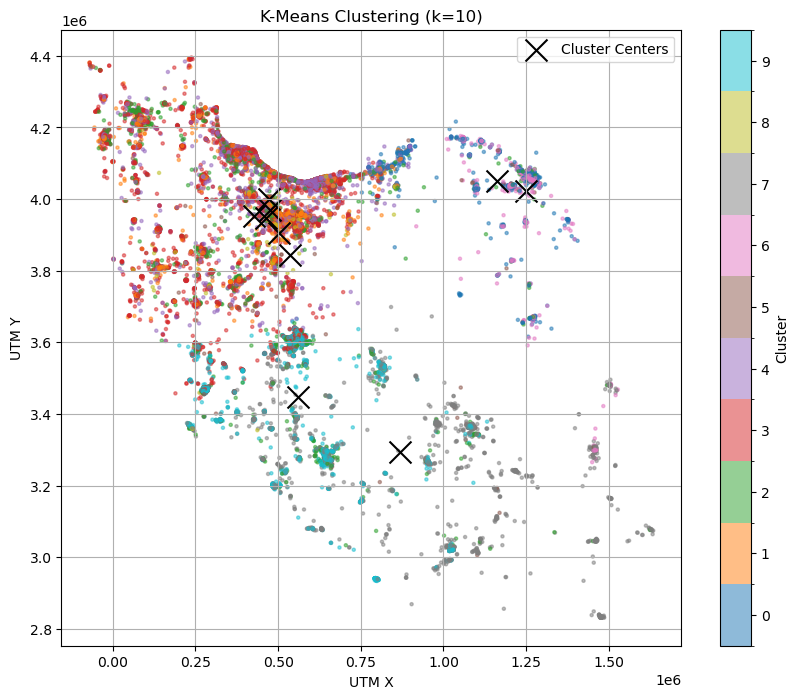

In [41]:
plot_kmeans_clusters(
    df=df_rec,
    centers_df=centers_10_df,
    cluster_col_name="cluster_kmeans_10",
    title="K-Means Clustering (k=10)",
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap_name="tab10"
)

In [42]:
centers_10_df

,log_price,building_size,utm_x,utm_y,has_parking,has_elevator,center_price
0,20.92,152.42,1163055.05,4049271.83,0.01,0.06,1.213994e+09
1,22.31,106.31,476530.94,3969962.70,1.00,1.00,4.892542e+09
2,21.53,707.25,503212.09,3904520.75,0.11,0.01,2.244475e+09
3,21.43,137.10,425583.66,3952358.67,0.00,0.00,2.023752e+09
4,21.81,125.17,473526.91,3999691.86,1.00,0.00,2.978129e+09
5,14.51,132.14,536368.67,3843013.20,0.62,0.30,1.999071e+06
6,21.98,129.27,1250699.38,4022593.06,1.00,0.59,3.500621e+09
7,21.04,200.27,868623.74,3294186.46,0.15,0.03,1.370855e+09
8,21.57,75.09,463794.25,3946984.39,0.00,1.00,2.335728e+09
9,22.10,137.15,558828.14,3446451.30,1.00,0.56,3.955222e+09


In [43]:
wcss = []

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    print(k, kmeans.inertia_)

1 2089331.9999999974
2 1617416.3260323273
3 1387234.0836027265
4 1191501.7460446376
5 1023343.716657285
6 892964.4556946185
7 779012.6407260962
8 727111.2117516699
9 675607.6680927131
10 640134.532906559
11 605706.0211975385
12 569969.9329008764
13 538325.2310613517
14 506527.28051954886
15 486859.1775783425
16 461549.76177026413
17 444834.26356540574
18 425768.4497861586
19 410008.20654260955
20 395907.22113135963


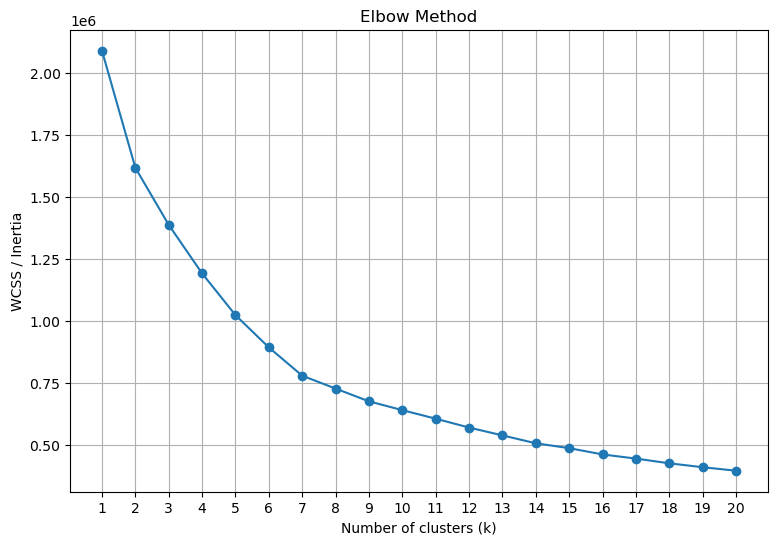

In [44]:
plt.figure(figsize=(9, 6))

plt.plot(list(K_RANGE), wcss, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")
plt.xticks(list(K_RANGE))
plt.grid(True)
plt.show()

In [45]:
sample_df = df_rec.sample(n=SCORE_SAMPLE_SIZE, random_state=RANDOM_STATE)

X_sample = sample_df[feature_cols].copy()

sample_scaler = StandardScaler()

X_sample_scaled = sample_scaler.fit_transform(X_sample)

silhouette_scores = []

for k in K_RANGE_SIL:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample_scaled)
    score = silhouette_score(X_sample_scaled, labels)
    
    silhouette_scores.append(score)
    print(k, score)

2 0.29118697632074064
3 0.26615909894234935
4 0.29180276955307677
5 0.3150844683003756
6 0.34268161906932154
7 0.3576927877980429
8 0.35565142607018096
9 0.37844500065737763
10 0.3789175609589844
11 0.38809486737957843
12 0.3983883301869155
13 0.3434532613385623
14 0.33386324845198617
15 0.34826060113252244
16 0.33195317429365323
17 0.35365619199779014
18 0.34356032168763895
19 0.3521323856836538
20 0.33059481972452526


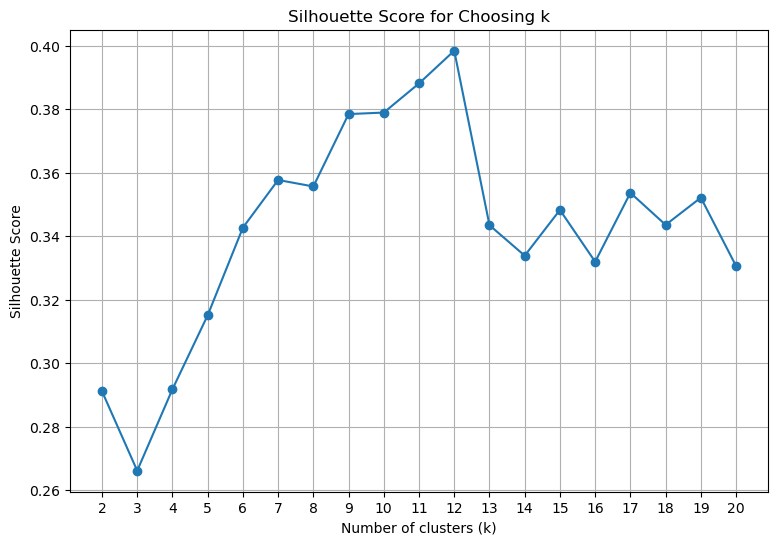

In [46]:
plt.figure(figsize=(9, 6))

plt.plot(list(K_RANGE_SIL), silhouette_scores, marker="o")

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Choosing k")
plt.xticks(list(K_RANGE_SIL))
plt.grid(True)
plt.show()

In [47]:
sample_df = df_rec.sample(n=SCORE_SAMPLE_SIZE, random_state=RANDOM_STATE)

X_sample = sample_df[feature_cols].copy()

sample_scaler = StandardScaler()
X_sample_scaled = sample_scaler.fit_transform(X_sample)

results = []

for k in range(2, 21):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_sample_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_sample_scaled, labels)
    calinski = calinski_harabasz_score(X_sample_scaled, labels)
    davies = davies_bouldin_score(X_sample_scaled, labels)
    
    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })

k_results = pd.DataFrame(results)
k_results

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,92865.398032,0.291187,5843.277586,1.636297
1,3,79511.867959,0.266159,5091.322825,1.580488
2,4,68329.141573,0.291803,5040.392020,1.404740
3,5,58756.025315,0.315084,5210.422268,1.225850
4,6,51244.540309,0.342682,5365.241759,1.128737
5,7,44879.377897,0.357693,5577.493376,1.039925
6,8,41839.633324,0.355651,5335.278869,1.096618
7,9,39085.104486,0.378445,5173.230758,1.065317
8,10,37050.374738,0.378918,4972.704359,1.054084
9,11,35111.187739,0.388095,4832.771195,1.045387


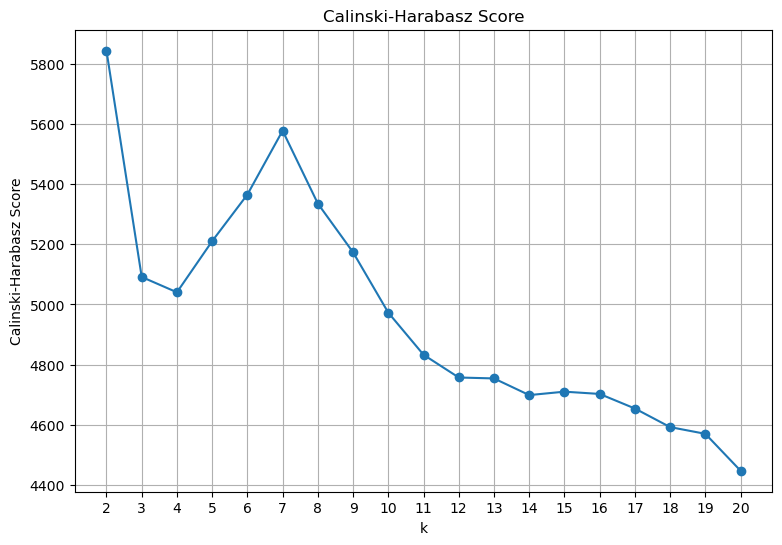

In [48]:
plt.figure(figsize=(9, 6))
plt.plot(k_results["k"], k_results["calinski_harabasz"], marker="o")
plt.xlabel("k")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Score")
plt.xticks(k_results["k"])
plt.grid(True)
plt.show()

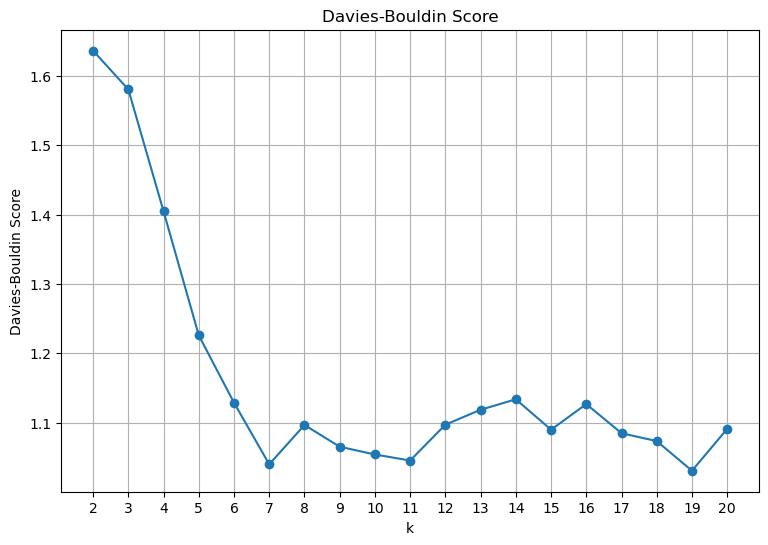

In [49]:
plt.figure(figsize=(9, 6))
plt.plot(k_results["k"], k_results["davies_bouldin"], marker="o")
plt.xlabel("k")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Score")
plt.xticks(k_results["k"])
plt.grid(True)
plt.show()

In [50]:
BEST_K = 7

In [51]:
kmeans_best, centers_best_df, counts_best = run_kmeans_clustering(
    df=df_rec,
    X_scaled=X_scaled,
    scaler=scaler,
    feature_cols=feature_cols,
    bool_cols=bool_cols,
    n_clusters=BEST_K,
    cluster_col_name="cluster_kmeans_best",
    random_state=RANDOM_STATE
)

counts_best

cluster_kmeans_best
0     88530
1    110654
2     25216
3      4792
4     30070
5     15724
6     73236
Name: count, dtype: int64

In [52]:
centers_best_df

,log_price,building_size,utm_x,utm_y,has_parking,has_elevator,center_price
0,21.42,127.29,440864.61,3950261.24,0.00,0.16,2.003340e+09
1,22.30,107.45,476594.90,3932949.92,1.00,1.00,4.836972e+09
2,21.66,129.92,1241989.43,4042246.79,0.67,0.41,2.554431e+09
3,14.54,132.72,542347.69,3840392.39,0.61,0.30,2.068815e+06
4,21.60,170.25,804090.11,3281191.08,0.56,0.31,2.399993e+09
5,21.50,690.08,523725.39,3900814.83,0.10,0.01,2.165506e+09
6,21.83,127.39,470942.70,3951116.35,1.00,0.00,3.011424e+09


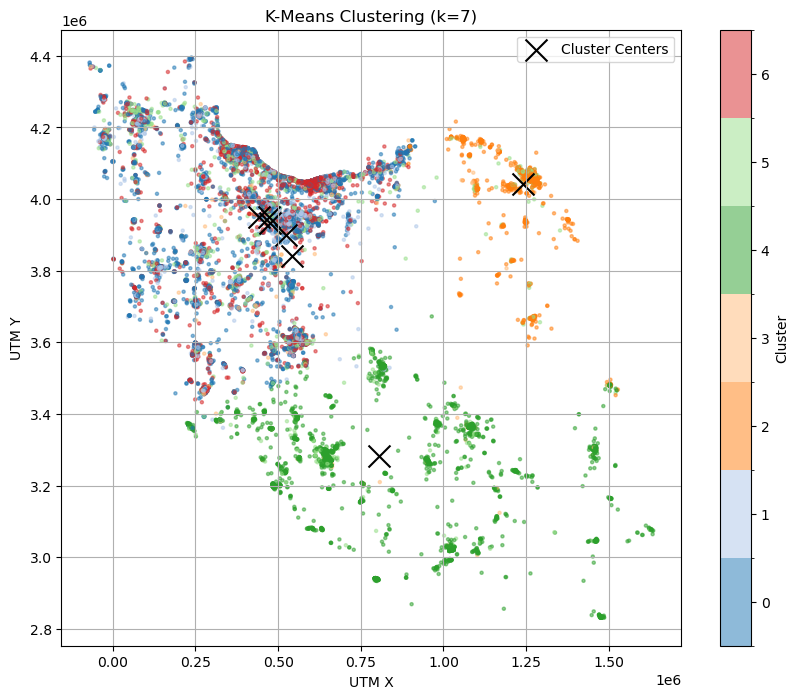

In [53]:
plot_kmeans_clusters(
    df=df_rec,
    centers_df=centers_best_df,
    cluster_col_name="cluster_kmeans_best",
    title=f"K-Means Clustering (k={BEST_K})",
    sample_size=PLOT_SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    cmap_name="tab20"
)

In [54]:
def summarize_clusters(df, cluster_col_name, feature_cols):
    agg_dict = {
        "count": ("price_value", "count")
    }

    if "price_value" in df.columns:
        agg_dict["mean_price"] = ("price_value", "mean")
        agg_dict["median_price"] = ("price_value", "median")

    for col in feature_cols:
        if col == "log_price":
            continue
        
        if col in df.columns:
            agg_dict[f"mean_{col}"] = (col, "mean")

    summary = df.groupby(cluster_col_name).agg(**agg_dict)

    if "mean_price" in summary.columns:
        summary["mean_price_billion"] = summary["mean_price"] / 1e9

    if "median_price" in summary.columns:
        summary["median_price_billion"] = summary["median_price"] / 1e9

    return summary.round(2)

In [55]:
summary_10 = summarize_clusters(df_rec, "cluster_kmeans_10", feature_cols)
summary_10

,count,mean_price,median_price,mean_building_size,mean_utm_x,mean_utm_y,mean_has_parking,mean_has_elevator,mean_price_billion,median_price_billion
cluster_kmeans_10,,,,,,,,,,
0,10813,2.420887e+09,1.200000e+09,152.42,1163055.05,4049271.83,0.01,0.06,2.42,1.20
1,100250,7.760522e+09,4.700000e+09,106.31,476530.94,3969962.70,1.00,1.00,7.76,4.70
2,14584,6.550422e+09,2.000000e+09,707.27,503210.56,3904538.97,0.11,0.01,6.55,2.00
3,71827,4.100494e+09,1.900000e+09,137.08,425580.44,3952413.70,0.00,0.00,4.10,1.90
4,65064,4.513308e+09,2.730000e+09,125.18,473531.44,3999821.53,1.00,0.00,4.51,2.73
5,4728,6.586540e+06,2.205000e+06,132.14,536368.67,3843013.20,0.62,0.30,0.01,0.00
6,17231,5.036590e+09,3.480000e+09,129.27,1250711.45,4022551.11,1.00,0.59,5.04,3.48
7,16772,2.821985e+09,1.450000e+09,200.33,868154.01,3294304.43,0.15,0.03,2.82,1.45
8,14385,2.913746e+09,2.300000e+09,75.09,463794.25,3946984.39,0.00,1.00,2.91,2.30


In [56]:
summary_best = summarize_clusters(df_rec, "cluster_kmeans_best", feature_cols)
summary_best

,count,mean_price,median_price,mean_building_size,mean_utm_x,mean_utm_y,mean_has_parking,mean_has_elevator,mean_price_billion,median_price_billion
cluster_kmeans_best,,,,,,,,,,
0,88530,3.783587e+09,1.950000e+09,127.30,440860.28,3950253.70,0.00,0.16,3.78,1.95
1,110654,7.575751e+09,4.620000e+09,107.44,476595.94,3932950.30,1.00,1.00,7.58,4.62
2,25216,4.288642e+09,2.700000e+09,129.92,1241989.43,4042246.79,0.67,0.41,4.29,2.70
3,4792,6.869750e+06,2.300000e+06,132.68,542348.39,3840341.54,0.61,0.30,0.01,0.00
4,30070,4.365558e+09,2.600000e+09,170.24,804109.11,3281188.46,0.56,0.31,4.37,2.60
5,15724,6.399922e+09,2.000000e+09,690.10,523742.64,3900817.63,0.10,0.01,6.40,2.00
6,73236,4.530176e+09,2.800000e+09,127.39,470942.70,3951116.35,1.00,0.00,4.53,2.80


In [57]:
dbscan_cols = [
    "utm_x",
    "utm_y",
    "log_price"
]

df_dbscan = df_rec[dbscan_cols].copy()

In [58]:
print(df_dbscan.shape)
print(df_dbscan.isna().sum())
df_dbscan.head()

(348222, 3)
utm_x        0
utm_y        0
log_price    0
dtype: int64


,utm_x,utm_y,log_price
2,5.457116e+05,3.954101e+06,22.886589
3,4.814371e+05,3.952066e+06,20.292483
4,5.684670e+05,3.959664e+06,21.678777
6,1.266003e+06,4.053542e+06,23.287446
7,5.379740e+05,3.592362e+06,20.560747


In [59]:
dbscan_scaler = StandardScaler()

In [60]:
df_dbscan_sample = df_dbscan.sample( 
    n=DBSCAN_SAMPLE_SIZE,
    random_state=RANDOM_STATE
).copy()

X_dbscan_sample = dbscan_scaler.fit_transform(df_dbscan_sample)

In [61]:
def eval_dbscan(X_scaled, eps, min_samples):
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )
    
    labels = dbscan.fit_predict(X_scaled)
    
    unique_labels = set(labels)
    
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels)
    
    return {
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "noise_ratio": noise_ratio
    }

In [62]:
def summarize_dbscan_clusters(df, cluster_col_name):
    summary = df.groupby(cluster_col_name).agg(
        count=("log_price", "count"),
        mean_utm_x=("utm_x", "mean"),
        mean_utm_y=("utm_y", "mean"),
        mean_log_price=("log_price", "mean"),
        median_log_price=("log_price", "median")
    )
    
    summary["mean_price"] = np.expm1(summary["mean_log_price"])
    summary["median_price"] = np.expm1(summary["median_log_price"])
    
    summary["mean_price_billion"] = summary["mean_price"] / 1e9
    summary["median_price_billion"] = summary["median_price"] / 1e9
    
    return summary.round(2)

In [63]:
def plot_dbscan_clusters(
    df,
    cluster_col_name,
    title,
    x_col="utm_x",
    y_col="utm_y",
    sample_size=None,
    random_state=RANDOM_STATE,
    cmap_name="tab10"
):
    if sample_size is not None and len(df) > sample_size:
        plot_df = df.sample(n=sample_size, random_state=random_state)
    else:
        plot_df = df.copy()
    
    labels = sorted(plot_df[cluster_col_name].unique())
    
    base_cmap = plt.get_cmap(cmap_name)
    colors = [base_cmap(i) for i in range(len(labels))]
    
    cmap = ListedColormap(colors)
    
    bounds = np.arange(len(labels) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)
    
    label_to_index = {label: i for i, label in enumerate(labels)}
    color_values = plot_df[cluster_col_name].map(label_to_index)
    
    plt.figure(figsize=(10, 8))
    
    scatter = plt.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=color_values,
        s=5,
        alpha=0.5,
        cmap=cmap,
        norm=norm
    )
    
    cbar = plt.colorbar(
        scatter,
        ticks=range(len(labels))
    )
    
    cbar.ax.set_yticklabels(labels)
    cbar.set_label("Cluster")
    
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [64]:
dbscan_results = []

eps_values = [0.5, 0.52, 0.55, 0.57, 0.6, 0.62, 0.65, 0.67]
min_samples_values = [200, 300, 400, 500, 1000, 1200]

for eps in eps_values:
    for min_samples in min_samples_values:
        result = eval_dbscan(
            X_dbscan_sample,
            eps=eps,
            min_samples=min_samples
        )

        dbscan_results.append(result)

dbscan_results_df = pd.DataFrame(dbscan_results)


dbscan_results_df.sort_values(
    ["n_clusters", "noise_ratio"]
)

,eps,min_samples,n_clusters,n_noise,noise_ratio
42,0.67,200,1,1970,0.03940
36,0.65,200,1,2029,0.04058
30,0.62,200,1,2147,0.04294
24,0.60,200,1,2236,0.04472
45,0.67,500,1,3157,0.06314
43,0.67,300,2,2244,0.04488
37,0.65,300,2,2361,0.04722
18,0.57,200,2,2377,0.04754
31,0.62,300,2,2509,0.05018
44,0.67,400,2,2607,0.05214


In [65]:
dbscan_results_cluster3_df = dbscan_results_df[
    dbscan_results_df["n_clusters"] == 3
].sort_values("noise_ratio")

dbscan_results_cluster3_df

,eps,min_samples,n_clusters,n_noise,noise_ratio
12,0.55,200,3,2475,0.04950
25,0.60,300,3,2614,0.05228
6,0.52,200,3,2666,0.05332
0,0.50,200,3,2860,0.05720
19,0.57,300,3,2963,0.05926
13,0.55,300,3,3145,0.06290
7,0.52,300,3,3541,0.07082
1,0.50,300,3,4201,0.08402
15,0.55,500,3,4290,0.08580
8,0.52,400,3,4304,0.08608


In [71]:
DBSCAN_EPS = 0.67
DBSCAN_MIN_SAMPLES = 1200

dbscan_best = DBSCAN(
    eps=DBSCAN_EPS,
    min_samples=DBSCAN_MIN_SAMPLES
)

df_dbscan_sample["cluster_dbscan"] = dbscan_best.fit_predict(X_dbscan_sample)

df_dbscan_sample["cluster_dbscan"].value_counts().sort_index()

cluster_dbscan
-1     5721
 0    39324
 1     3322
 2     1633
Name: count, dtype: int64

In [72]:
summary_dbscan = summarize_dbscan_clusters(
    df_dbscan_sample, 
    "cluster_dbscan"
)

summary_dbscan

,count,mean_utm_x,mean_utm_y,mean_log_price,median_log_price,mean_price,median_price,mean_price_billion,median_price_billion
cluster_dbscan,,,,,,,,,
-1,5721,673892.77,3546466.81,20.25,20.62,6.201780e+08,9.000000e+08,0.62,0.90
0,39324,472225.39,3950249.40,21.93,21.85,3.329961e+09,3.100000e+09,3.33,3.10
1,3322,1243613.79,4057450.21,21.70,21.75,2.664798e+09,2.800000e+09,2.66,2.80
2,1633,635244.06,3275156.04,22.13,22.15,4.070876e+09,4.180000e+09,4.07,4.18


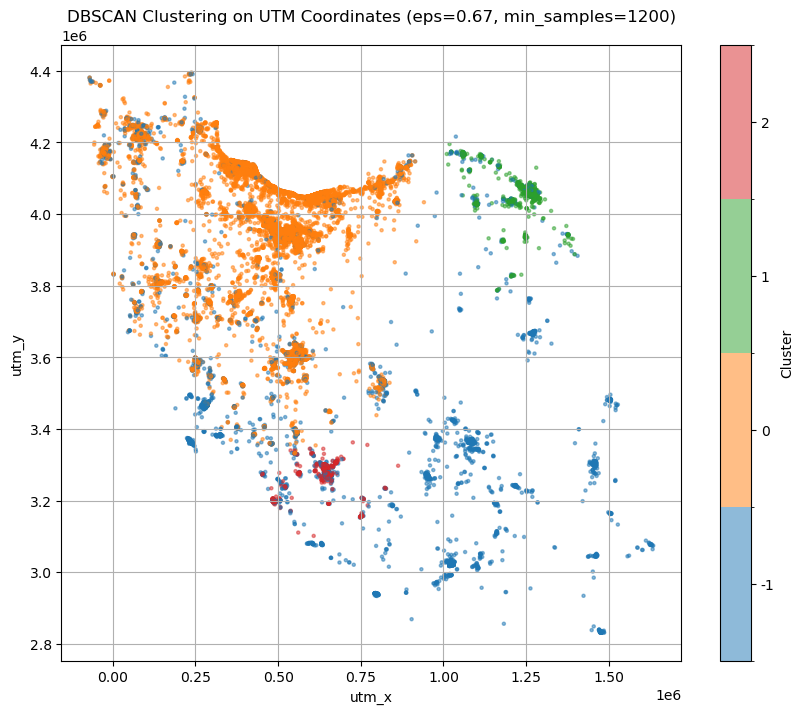

In [73]:
plot_dbscan_clusters(
    df=df_dbscan_sample,
    cluster_col_name="cluster_dbscan",
    title=f"DBSCAN Clustering on UTM Coordinates (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})",
    x_col="utm_x",
    y_col="utm_y",
)

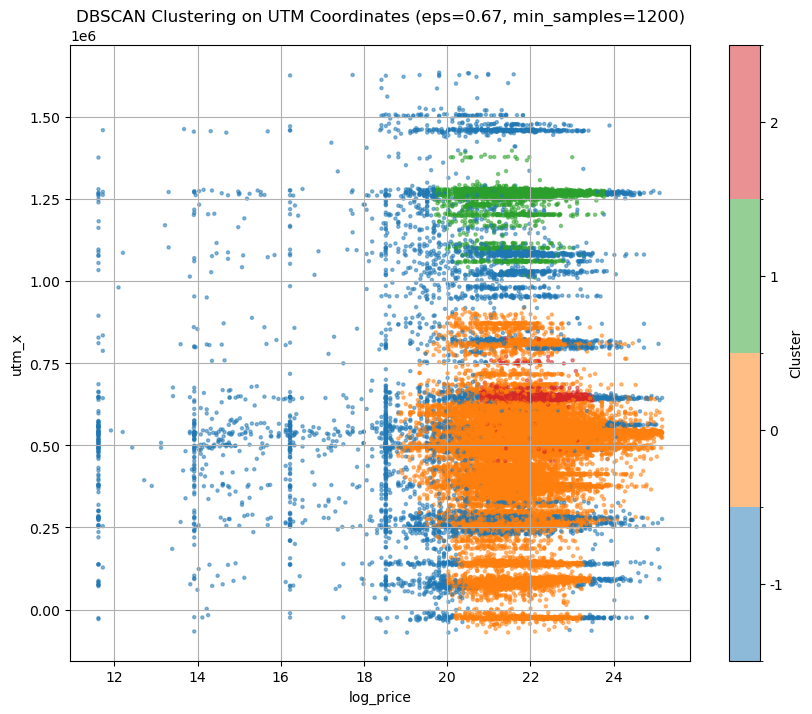

In [74]:
plot_dbscan_clusters(
    df=df_dbscan_sample,
    cluster_col_name="cluster_dbscan",
    title=f"DBSCAN Clustering on UTM Coordinates (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})",
    x_col="log_price",
    y_col="utm_x",
)

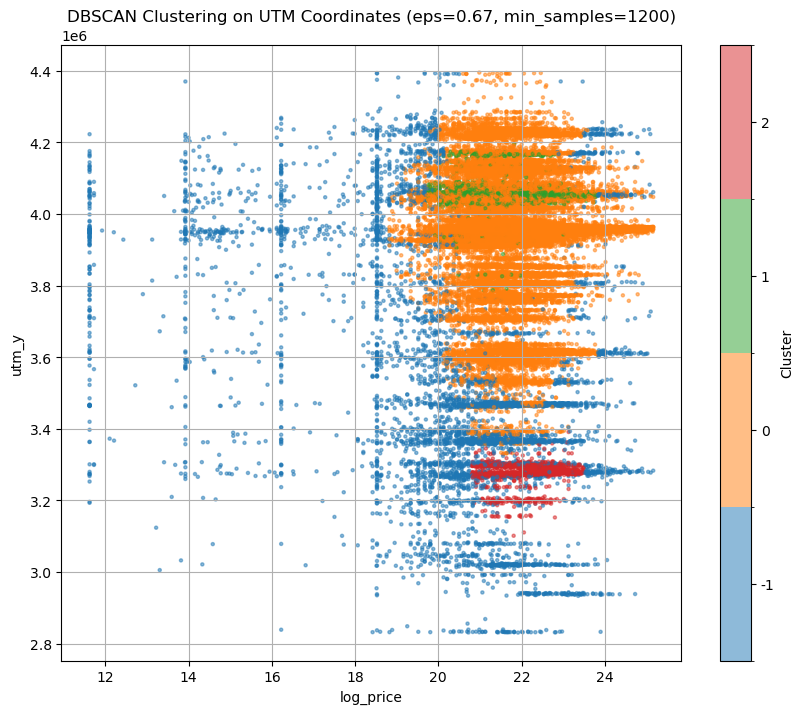

In [75]:
plot_dbscan_clusters(
    df=df_dbscan_sample,
    cluster_col_name="cluster_dbscan",
    title=f"DBSCAN Clustering on UTM Coordinates (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES})",
    x_col="log_price",
    y_col="utm_y",
)